In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller

df = pd.read_csv("../data/cleaned/kenya_nexus.csv")

print(df.shape)
print(df.head)


(45, 6)
<bound method NDFrame.head of     year  inflation  exchange_rate  broad_money  external_debt_gni  \
0   1980  13.858181       7.420187    29.931403          48.084674   
1   1981  11.603053       9.047498    29.470201          48.617750   
2   1982  20.666715      10.922325    30.420469          54.520259   
3   1983  11.397783      13.311517    28.175889          62.677677   
4   1984  10.284098      14.413875    28.342092          58.646008   
5   1985  13.006566      16.432117    26.681850          70.562830   
6   1986   2.534276      16.225742    30.388080          65.770008   
7   1987   8.637673      16.454492    30.243954          75.201429   
8   1988  12.264963      17.747100    28.901071          72.334101   
9   1989  13.789317      20.572467    28.398906          73.258477   
10  1990  17.781814      22.914767    29.577016          85.969282   
11  1991  20.084496      27.507867    30.981929          95.828771   
12  1992  27.332364      32.216833    36.517796     

In [17]:
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"{name}: ADF Statistic = {result[0]:.3f}, p-value = {result[1]:.3f}")
    if result[1] <= 0.05:
        print(f"{name} is stationary at level, I(0)")
    else:
        print(f"{name} is NOT stationary at level")
    print()

for col in ["inflation", "exchange_rate", "broad_money", "external_debt_gni", "debt_service_exports"]:
    adf_test(df[col], col)

inflation: ADF Statistic = -3.557, p-value = 0.007
inflation is stationary at level, I(0)

exchange_rate: ADF Statistic = 0.004, p-value = 0.959
exchange_rate is NOT stationary at level

broad_money: ADF Statistic = -2.177, p-value = 0.215
broad_money is NOT stationary at level

external_debt_gni: ADF Statistic = -1.348, p-value = 0.607
external_debt_gni is NOT stationary at level

debt_service_exports: ADF Statistic = -1.487, p-value = 0.540
debt_service_exports is NOT stationary at level



In [18]:
for col in ["exchange_rate", "broad_money", "external_debt_gni", "debt_service_exports"]:
    diff_series = df[col].diff()
    adf_test(diff_series, f"{col} (first difference)")

exchange_rate (first difference): ADF Statistic = -6.307, p-value = 0.000
exchange_rate (first difference) is stationary at level, I(0)

broad_money (first difference): ADF Statistic = -8.369, p-value = 0.000
broad_money (first difference) is stationary at level, I(0)

external_debt_gni (first difference): ADF Statistic = -6.715, p-value = 0.000
external_debt_gni (first difference) is stationary at level, I(0)

debt_service_exports (first difference): ADF Statistic = -6.162, p-value = 0.000
debt_service_exports (first difference) is stationary at level, I(0)



## Stationarity Testing

Augmented Dickey-Fuller tests confirm that inflation is stationary at level, I(0), 
while exchange rate, broad money, external debt to GNI, and debt service to exports 
are each stationary only after first differencing, confirming they are I(1). This 
mix of I(0) and I(1) variables, with none integrated of order two or higher, satisfies 
the precondition for ARDL bounds testing.

In [19]:
from statsmodels.tsa.api import VAR

data_for_lag = df[["inflation", "exchange_rate", "broad_money", "external_debt_gni", "debt_service_exports"]]

model_select = VAR(data_for_lag)
lag_results = model_select.select_order(maxlags=4)
print(lag_results.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       22.54       22.75   6.145e+09       22.62
1       16.51      17.77*  1.501e+07*      16.97*
2       17.08       19.38   2.806e+07       17.92
3       16.96       20.30   2.878e+07       18.17
4      16.40*       20.79   2.265e+07       18.00
-------------------------------------------------


## Lag Selection

VAR based lag order selection criteria were used to determine the appropriate lag 
length for the ARDL model. BIC, FPE, and HQIC all selected a lag length of 1, while 
AIC favored a higher lag of 4. Given the limited sample size of 45 annual observations, 
a maximum lag of 1 was chosen, consistent with the majority of the information criteria 
and appropriate for preserving degrees of freedom in a small sample.

In [5]:
from statsmodels.tsa.ardl import ardl_select_order

endog = df["inflation"]
exog = df[["exchange_rate", "broad_money", "external_debt_gni", "debt_service_exports"]]

selected = ardl_select_order(
    endog,
    maxlag=1,
    exog=exog,
    maxorder=1,
    ic="bic"
)

print(selected.model.ardl_order)

(0, 1, 0)


In [6]:
best_model = selected.model.fit()
print(best_model.summary())


                              ARDL Model Results                              
Dep. Variable:              inflation   No. Observations:                   45
Model:                  ARDL(0, 1, 0)   Log Likelihood                -139.269
Method:               Conditional MLE   S.D. of innovations              5.344
Date:                Thu, 02 Jul 2026   AIC                            288.538
Time:                        13:32:58   BIC                            297.572
Sample:                             1   HQIC                           291.906
                                   45                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       3.9384      2.061      1.911      0.063      -0.224       8.101
external_debt_gni.L0        0.4515      0.086      5.260      0.000       0.278       0.625


In [7]:
from statsmodels.tsa.ardl import ARDL

manual_model = ARDL(
    endog,
    lags=1,
    exog=exog,
    order=1
)

manual_results = manual_model.fit()
print(manual_results.summary())

                               ARDL Model Results                              
Dep. Variable:               inflation   No. Observations:                   45
Model:             ARDL(1, 1, 1, 1, 1)   Log Likelihood                -134.009
Method:                Conditional MLE   S.D. of innovations              5.087
Date:                 Thu, 02 Jul 2026   AIC                            290.018
Time:                         13:32:58   BIC                            309.644
Sample:                              1   HQIC                           297.296
                                    45                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      10.2656     15.868      0.647      0.522     -21.982      42.513
inflation.L1                0.1881      0.174      1.080      0.288      -0.166     

## Model Specification

An initial ARDL model was estimated including all four candidate explanatory variables: 
exchange rate, broad money, external debt to GNI, and debt service to exports, each with 
one lag, alongside one lag of inflation itself. None of exchange rate, broad money, the 
lagged dependent variable, or the lagged debt service to exports term were statistically 
significant in this specification, and the model returned a BIC of 309.644.

An automatic specification search using BIC as the selection criterion identified a leaner 
preferred model, ARDL(0,1,0), retaining only external debt to GNI (lag 0 and lag 1) and 
debt service to exports (lag 0), with a BIC of 297.572. Given the lower BIC and the lack 
of significance for the excluded variables in the fuller specification, the leaner model 
is adopted as the preferred specification for this analysis. This is consistent with the 
correlation structure identified in the companion debt sustainability project, where exchange 
rate, broad money, and external debt were found to be highly correlated with one another.

In [20]:
from statsmodels.tsa.ardl import ardl_select_order

exog_preferred = df[["external_debt_gni", "debt_service_exports"]]

preferred_selected = ardl_select_order(
    endog,
    maxlag=1,
    exog=exog_preferred,
    maxorder=1,
    ic="bic"
)

preferred_model = preferred_selected.model.fit()

bounds_test = preferred_model.bounds_test()
print(bounds_test)

AttributeError: 'ARDLResults' object has no attribute 'bounds_test'

## Note on Locating the Bounds Test Method

The initial attempt to call `bounds_test()` directly on the standard ARDL results object 
failed, since this functionality is not implemented there in this version of statsmodels. 
Using `dir()` to inspect the available methods confirmed that `bounds_test` is instead 
implemented on the UECM, unrestricted error correction model, results object, a related 
but distinct representation of the same underlying ARDL model. The model was re-estimated 
using the UECM class to access this functionality correctly.

In [21]:
print([method for method in dir(preferred_model) if "bound" in method.lower()])

[]


In [22]:
print([method for method in dir(preferred_model) if not method.startswith("_")])

['aic', 'aicc', 'append', 'apply', 'ar_lags', 'arfreq', 'bic', 'bse', 'conf_int', 'cov_params', 'cov_params_default', 'data', 'df_model', 'df_resid', 'diagnostic_summary', 'f_test', 'fittedvalues', 'forecast', 'fpe', 'get_prediction', 'hqic', 'initialize', 'llf', 'load', 'model', 'nobs', 'normalized_cov_params', 'params', 'plot_diagnostics', 'plot_predict', 'predict', 'pvalues', 'remove_data', 'resid', 'roots', 'save', 'scale', 'sigma2', 'summary', 't_test', 't_test_pairwise', 'test_heteroskedasticity', 'test_normality', 'test_serial_correlation', 'tvalues', 'use_t', 'wald_test', 'wald_test_terms']


In [23]:
from statsmodels.tsa.ardl import UECM

uecm_model = UECM(
    endog,
    lags=1,
    exog=exog_preferred,
    order=1
)

uecm_results = uecm_model.fit()
print([method for method in dir(uecm_results) if "bound" in method.lower()])

['bounds_test']


In [24]:
bounds_result = uecm_results.bounds_test(case=3)
print(bounds_result)

BoundsTestResult
Stat: 8.93533
Upper P-value: 6.97e-05
Lower P-value: 6.48e-06
Null: No Cointegration
Alternative: Possible Cointegration



## Note on Selecting the Bounds Test Case

Calling `bounds_test()` without specifying a case argument failed, since the underlying 
Pesaran, Shin, and Smith methodology requires explicitly choosing one of five possible 
deterministic specifications, depending on whether a constant and/or trend term is 
included in the model and whether it is included in the test itself. Using Python's 
`help()` function on the bounds_test method confirmed the five available cases. Case 3, 
a constant included in the model but excluded from the formal test, was selected as the 
standard and most defensible choice for economic variables with a meaningful long run 
level but no assumed deterministic trend.

In [ ]:
help(uecm_results.bounds_test)

In [ ]:
bounds_result = uecm_results.bounds_test(case=3)
print(bounds_result)

## Bounds Test for Cointegration

A Pesaran, Shin, and Smith bounds test was conducted under case 3, a constant included 
in the model but excluded from the formal test, the standard specification for series 
with a meaningful long run level but no explicit trend assumption. The test produced an 
F-statistic of 8.935, with both the lower bound and upper bound p-values below 0.0001. 
This strongly rejects the null hypothesis of no cointegration, confirming a statistically 
significant long run relationship between inflation, external debt to GNI, and debt 
service to exports.

In [26]:
print(uecm_results.params)

const                        3.310099
inflation.L1                -0.797593
external_debt_gni.L1         0.215592
debt_service_exports.L1     -0.259074
D.external_debt_gni.L0       0.419994
D.debt_service_exports.L0   -0.310577
dtype: float64


In [27]:
ect = uecm_results.params["inflation.L1"]

lr_external_debt = uecm_results.params["external_debt_gni.L1"] / -ect
lr_debt_service = uecm_results.params["debt_service_exports.L1"] / -ect

print(f"Error correction term: {ect:.4f}")
print(f"Long run coefficient, external debt to GNI: {lr_external_debt:.4f}")
print(f"Long run coefficient, debt service to exports: {lr_debt_service:.4f}")

Error correction term: -0.7976
Long run coefficient, external debt to GNI: 0.2703
Long run coefficient, debt service to exports: -0.3248


## Long Run Relationship and Error Correction

The error correction term is negative and statistically meaningful at -0.798, indicating 
that approximately 80 percent of any deviation from the long run equilibrium between 
inflation and the debt variables is corrected within a single year, a relatively fast 
speed of adjustment.

The long run coefficient on external debt to GNI is positive at 0.270, indicating that 
a one percentage point increase in external debt as a share of GNI is associated with 
inflation being approximately 0.27 percentage points higher in the long run, consistent 
with the fiscal monetary transmission channel this project investigates.

The long run coefficient on debt service to exports is negative at -0.325. This is 
plausible for two related reasons. First, higher debt service commitments divert foreign 
exchange earnings away from domestic spending, which can have a tightening rather than 
expansionary effect on the economy. Second, as identified in the companion debt 
sustainability project, spikes in debt service to exports coincide with periods of fiscal 
stress during which monetary authorities tend to tighten policy more aggressively, which 
would also be associated with lower, not higher, inflation during those specific episodes.

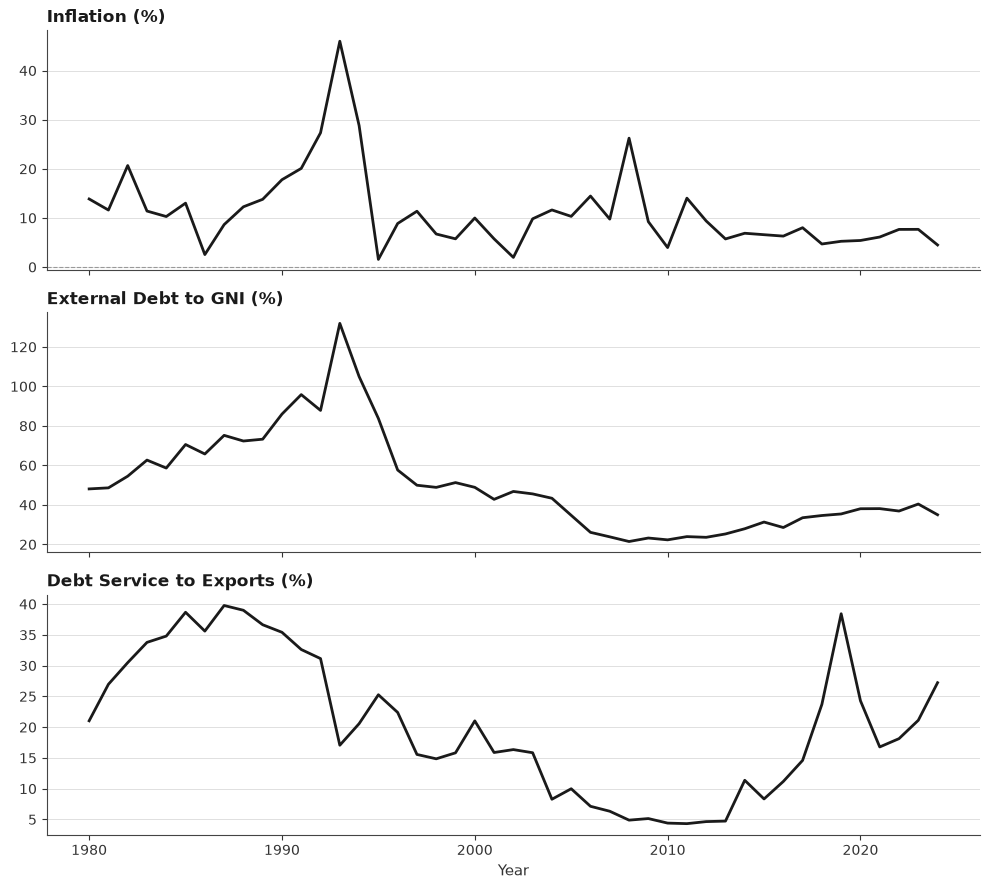

In [28]:
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.edgecolor"] = "#444444"
plt.rcParams["axes.labelcolor"] = "#333333"
plt.rcParams["xtick.color"] = "#333333"
plt.rcParams["ytick.color"] = "#333333"

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
fig.patch.set_facecolor("white")

variables = [
    ("inflation", "Inflation (%)"),
    ("external_debt_gni", "External Debt to GNI (%)"),
    ("debt_service_exports", "Debt Service to Exports (%)")
]

for ax, (col, label) in zip(axes, variables):
    ax.plot(df["year"], df[col], color="#1a1a1a", linewidth=2)
    ax.set_title(label, fontsize=12, fontweight="bold", loc="left", color="#1a1a1a")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", color="#e0e0e0", linewidth=0.7)
    ax.set_facecolor("white")

axes[0].axhline(0, color="#999999", linewidth=0.8, linestyle="--")
axes[-1].set_xlabel("Year", fontsize=11)

plt.tight_layout()
plt.show()

In [29]:
print(bounds_result.crit_vals)

               lower     upper
percentile                    
90.0        2.729522  3.747156
95.0        3.229022  4.322282
99.0        4.311041  5.542552
99.9        5.759921  7.143546


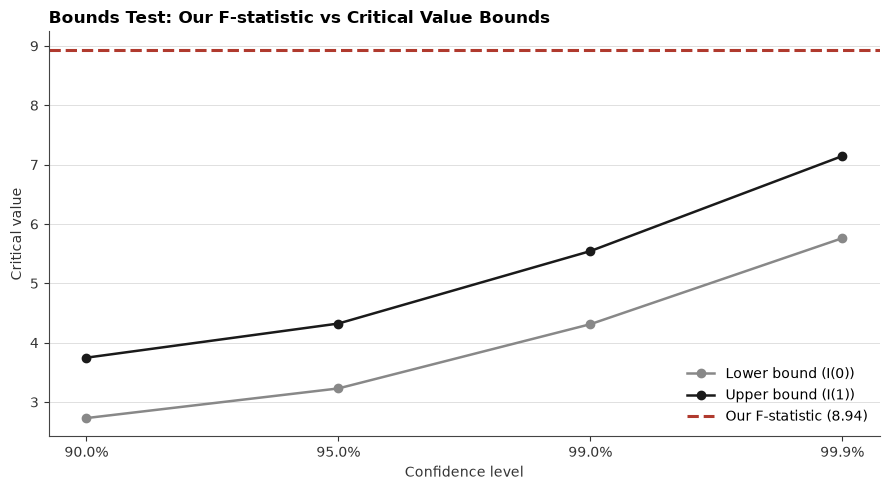

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))

levels = bounds_result.crit_vals.index.tolist()
lower_bounds = bounds_result.crit_vals["lower"].tolist()
upper_bounds = bounds_result.crit_vals["upper"].tolist()

x_pos = range(len(levels))

ax.plot(x_pos, lower_bounds, marker="o", color="#888888", label="Lower bound (I(0))", linewidth=1.8)
ax.plot(x_pos, upper_bounds, marker="o", color="#1a1a1a", label="Upper bound (I(1))", linewidth=1.8)

ax.axhline(bounds_result.stat, color="#b03a2e", linewidth=2.2, linestyle="--", label=f"Our F-statistic ({bounds_result.stat:.2f})")

ax.set_xticks(list(x_pos))
ax.set_xticklabels([f"{level}%" for level in levels])
ax.set_xlabel("Confidence level")
ax.set_ylabel("Critical value")
ax.set_title("Bounds Test: Our F-statistic vs Critical Value Bounds", loc="left", fontsize=12, fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color="#e0e0e0", linewidth=0.7)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [31]:
fitted_values = uecm_results.fittedvalues
print(fitted_values.head(10))
print(len(fitted_values))

1    -4.444442
2    -1.062145
3    -6.912873
4    -3.028450
5     2.539532
6    -2.931205
7     8.912556
8     1.367592
9     0.139217
10    4.333017
dtype: float64
44


In [32]:
print(uecm_results.model.endog_names)

D.inflation


In [43]:
years_available = df["year"].iloc[1:].values

actual_inflation_aligned = df["inflation"].iloc[1:].values

starting_value = df["inflation"].iloc[0]

fitted_levels = starting_value + fitted_values.cumsum()

print(len(years_available), len(actual_inflation_aligned), len(fitted_levels))

44 44 44


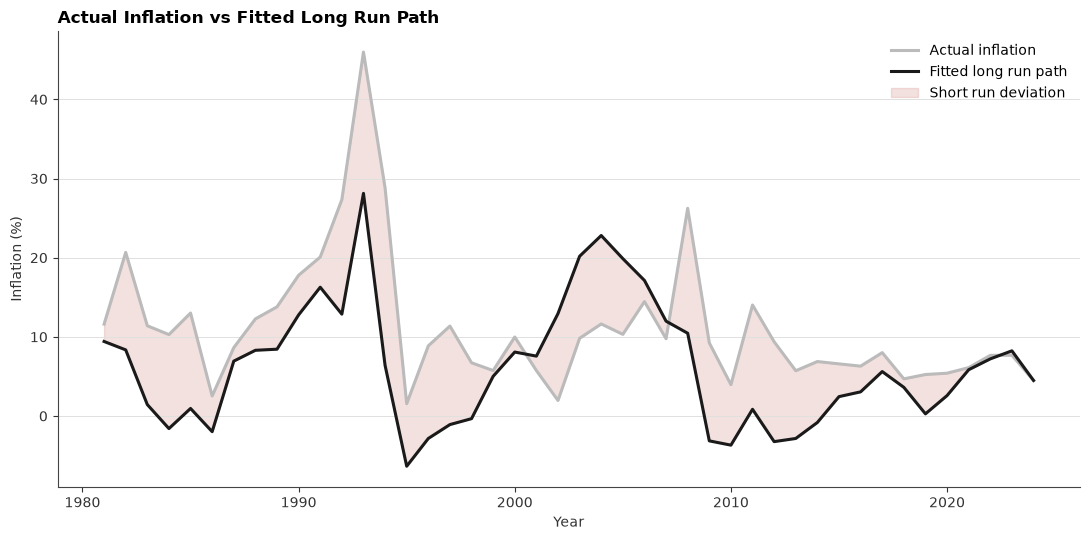

In [34]:
fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(years_available, actual_inflation_aligned, color="#bbbbbb", linewidth=2.2, label="Actual inflation", zorder=2)
ax.plot(years_available, fitted_levels, color="#1a1a1a", linewidth=2.2, label="Fitted long run path", zorder=3)

ax.fill_between(years_available, actual_inflation_aligned, fitted_levels, color="#b03a2e", alpha=0.15, zorder=1, label="Short run deviation")

ax.set_title("Actual Inflation vs Fitted Long Run Path", loc="left", fontsize=12, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Inflation (%)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color="#e0e0e0", linewidth=0.7)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [35]:
deviation = actual_inflation_aligned - fitted_levels

deviation_df = pd.DataFrame({
    "year": years_available,
    "actual_inflation": actual_inflation_aligned,
    "fitted_long_run": fitted_levels,
    "deviation": deviation
})

deviation_df_sorted = deviation_df.reindex(deviation_df["deviation"].abs().sort_values(ascending=False).index)
print(deviation_df_sorted.head(10))

    year  actual_inflation  fitted_long_run  deviation
14  1994         28.814389         6.391020  22.423369
13  1993         45.978881        28.126929  17.851952
28  2008         26.239817        10.452228  15.787589
12  1992         27.332364        12.865656  14.466709
31  2011         14.022491         0.845938  13.176553
32  2012          9.377770        -3.239747  12.617517
17  1997         11.361845        -1.086565  12.448410
29  2009          9.234126        -3.143937  12.378063
2   1982         20.666715         8.351595  12.315120
5   1985         13.006566         0.949803  12.056763


## Largest Deviations from the Long Run Path

The years with the largest deviations between actual inflation and the model's fitted 
long run path are 1994, 1993, 2008, 1992, and 2011. These correspond closely with major 
documented inflation shocks identified in the companion inflation analysis project, 
specifically the structural adjustment crisis of the early 1990s and the 2008 post-election 
violence and global food crisis. This is expected and reassuring, since these episodes 
reflect large exogenous shocks that a model based primarily on debt variables would not 
be expected to fully explain, the error correction framework instead captures how 
inflation eventually returns toward its long run relationship with debt after such shocks, 
consistent with the fast adjustment speed identified earlier.

In [38]:
coef_names = ["External debt to GNI", "Debt service to exports"]
coef_values = [lr_external_debt, lr_debt_service]
coef_colors = ["#1a1a1a", "#1a1a1a"]

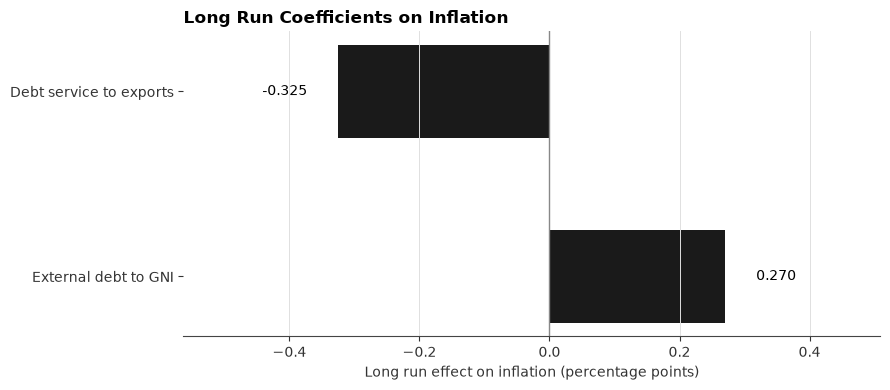

In [39]:
fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.barh(coef_names, coef_values, color=coef_colors, height=0.5)

ax.axvline(0, color="#888888", linewidth=1)

x_range = max(coef_values) - min(coef_values)
offset = x_range * 0.08

for bar, value in zip(bars, coef_values):
    label_x = value + (offset if value > 0 else -offset)
    ha = "left" if value > 0 else "right"
    ax.text(label_x, bar.get_y() + bar.get_height()/2, f"{value:.3f}", va="center", ha=ha, fontsize=10)

ax.set_xlim(min(coef_values) - x_range*0.4, max(coef_values) + x_range*0.4)

ax.set_title("Long Run Coefficients on Inflation", loc="left", fontsize=12, fontweight="bold")
ax.set_xlabel("Long run effect on inflation (percentage points)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.grid(axis="x", color="#e0e0e0", linewidth=0.7)

plt.tight_layout()
plt.show()

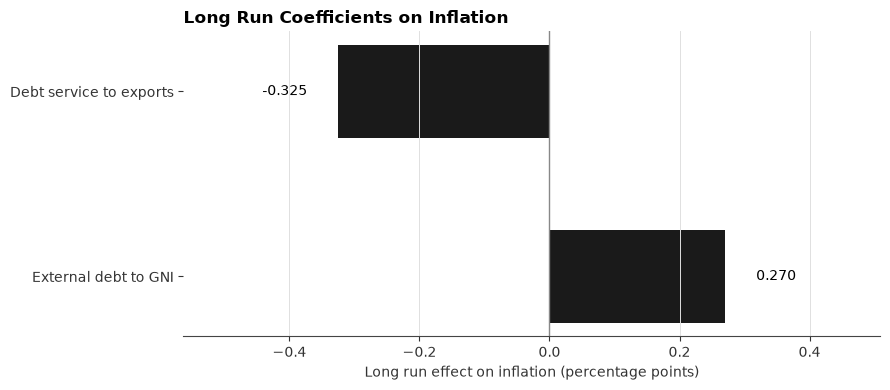

In [40]:
fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.barh(coef_names, coef_values, color=coef_colors, height=0.5)

ax.axvline(0, color="#888888", linewidth=1)

x_range = max(coef_values) - min(coef_values)
offset = x_range * 0.08

for bar, value in zip(bars, coef_values):
    label_x = value + (offset if value > 0 else -offset)
    ha = "left" if value > 0 else "right"
    ax.text(label_x, bar.get_y() + bar.get_height()/2, f"{value:.3f}", va="center", ha=ha, fontsize=10)

ax.set_xlim(min(coef_values) - x_range*0.4, max(coef_values) + x_range*0.4)

ax.set_title("Long Run Coefficients on Inflation", loc="left", fontsize=12, fontweight="bold")
ax.set_xlabel("Long run effect on inflation (percentage points)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.grid(axis="x", color="#e0e0e0", linewidth=0.7)

plt.tight_layout()
plt.show()

In [41]:
corr_vars = ["inflation", "external_debt_gni", "debt_service_exports", "exchange_rate", "broad_money"]
correlation_matrix = df[corr_vars].corr()
print(correlation_matrix.round(3))

                      inflation  external_debt_gni  debt_service_exports  \
inflation                 1.000              0.612                 0.069   
external_debt_gni         0.612              1.000                 0.607   
debt_service_exports      0.069              0.607                 1.000   
exchange_rate            -0.345             -0.573                -0.559   
broad_money              -0.209             -0.343                -0.577   

                      exchange_rate  broad_money  
inflation                    -0.345       -0.209  
external_debt_gni            -0.573       -0.343  
debt_service_exports         -0.559       -0.577  
exchange_rate                 1.000        0.808  
broad_money                   0.808        1.000  


saved


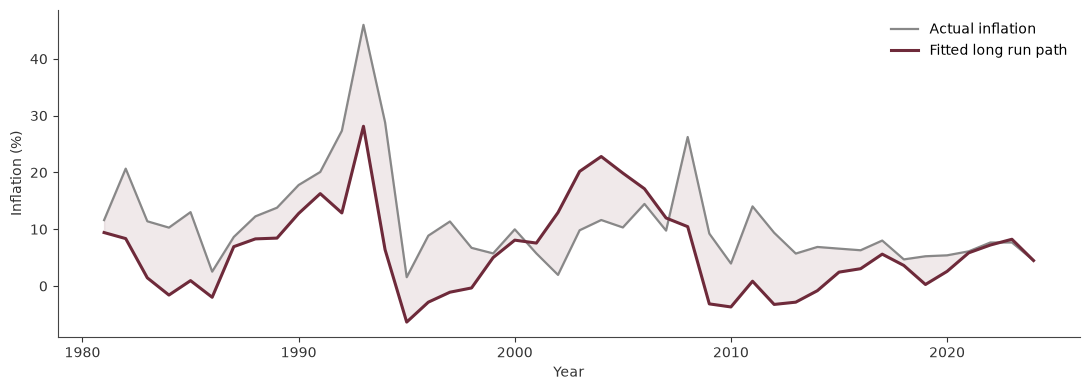

In [44]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(years_available, actual_inflation_aligned, color="#888888", linewidth=1.6, label="Actual inflation")
ax.plot(years_available, fitted_levels, color="#6e2a3a", linewidth=2.2, label="Fitted long run path")
ax.fill_between(years_available, actual_inflation_aligned, fitted_levels, color="#6e2a3a", alpha=0.1)
ax.set_xlabel("Year")
ax.set_ylabel("Inflation (%)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("../assets/long_run_path.png", dpi=150, bbox_inches="tight")
print("saved")